<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# some initialization stuff
%run ../init.py
%matplotlib inline

import nns.helpers as hp

<IPython.core.display.Latex object>

# Convolutional networks

- Processing data organized in a grid-like topology

## 1-D data - sequences and time-series

- Example: Consider a sequence of observations bbbbaabbbaabbbaabbbbaabbb
- Are there any patterns?

- bbbb**aa**bbb**aa**bbb**aa**bbbb**aa**bbb

## 2-D data - images
- Example:  Find Karli the small rabbit


<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/find-rabbit.jpg" width="60%"/>
</center>

<div style="cite"><a href="https://www.kinderpostershop.de/WebRoot/Store5/Shops/61444106/5BCC/5077/2B5C/21AD/D8B6/0A0C/6D04/0C17/Suchbild-Postkarte-Wimmelbild-Marion-Kratschmer.jpg">Image source</a></div>

## 3-D data - videos (sequences of images)

- An overlay image created out of a sequence of six images

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/bird-timelapse.jpg" width="60%"/>
</center>

<div style="cite"><a href="https://www.pexels.com/photo/timelapse-of-a-bird-landing-on-a-branch-5814467/">Image source</a></div>

## Issues with ANNs

- Images have very high dimensionality 
    - Most modern cameras output images with millions of pixels - vectors
    - $224 \times 224$ image typically used in modern computer vision systems has $50.176$ pixels
    - The first hidden layer with 10 neurons requires $501.760$ weights
    - Deep networks become infeasible to train
    
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/testout.png" width="10%"/>
</center>
    
- ANNs treat images as unstructured data
    - The order of features in the *Sales example* is irrelevant: `TV, Radio` or `Radio, TV`
    - Image processing requires recognizing local correlations between feature values of a highly dimensional input
    - Training an ANN with such a variance for image processing would require a lot of data
    


# Inductive bias: Designing a new type of networks

## Locality

<div class="myalert">Every feature of an observation is related to the ones positioned spatially or temporally near it</div>


- In time-series whatever happens at a time $t$ is highly likely related to the observation made st $t-1$
- Neighboring pixels of an image are related, otherwise we would be unable to recognize objects on an image
- Pixels observed on a frame at $t$ are related to pixels at a similar position on a frame at $t-1$

$\Rightarrow$ The model must consider only a small spatial or temporal neighborhood of the target vector

## Feature detectors

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/conv-detectors.svg" width="40%"/>
</center>

## Translational equivalence

<div class="myalert">An object in an image remains the same regardless of its position</div>

- The network must be able to generalize what it learned for one location to all possible locations
- Values of weights are shared by all units of a layer
- Given a position $k$ with corresponding weights $\vec{w}^k$ and a receptive field $\vec{f}$ 

$$conv1D(F_k) = \sum_{i} w^k_{i} f_{i}$$
$$conv2D(F_k) = \sum_{i,j} w^k_{ij} f_{ij}$$

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/conv1d.gif" width="100%"/>
</center>

## Convolutional layer
- *Convolution* is an operation on two functions, e.g., $f$ and $g$ that produces a third function $f*g$ expressing how the shape of $f$ is modified by the shape of $g$
- Convolutional layer comprises a set of functions (filters, kernels) that are used to transform the input
- Filters are applied "locally" to the previous layer
  - Significant reduction of the number of parameters in comparison to a dense layer where each unit "looks" at the whole input
  - Convolutional layers are locally connected, where each unit "focuses" on a small region of the input 
  - Learn feature detectors that are able to extract edges, corners, contours, etc.

## 2D Convolutional layer

- In a 2D case, each neuron in a layer applies a filter $W$ (i.e. a matrix of its weights) to a connected region $F$, i.e.  $conv(F) = \sum_{i,j} w_{ij} f_{ij}$
  - Often a convolutional layer has a set of filters that output a feature map (a set of convolutions)
  - Commonly, a linear rectification is applied to the output to introduce non-linearity which might improve the expressivity of multiple convolutional layers and make gradients sparse
- Filters of a layer are learned during the training process
- Definition of the locality of the filters is regulated by two parameters: 
    - *Stride* parameter defines how we move the filter
    - *Padding* how many zeros are used to preserve the spatial size of the input
- Activation maps produced by every filter are stacked together along the depth dimension to produce the overall output
- Often in practice neurons of a slice use the same weights and bias (parameter sharing) to reduce the training effort
  - Every neuron during the backpropagation computes own gradients for its weights
  - All gradients in a slice are added up and the weights in a slice are updated

- In PyTorch 2D convolution is defined as  

$$\text{out}(N_i, C_{\text{out}_j}) = \text{bias}(C_{\text{out}_j}) +
\sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)$$

- $\star$ is a *cross-correlation* operator
  - measures the correllation between entries of two of two random vectors
- Cross-corellation in signal processing
  - measure the similarity between the matrix of weights and the observation of a filter as a function of displacement of one relative to the other
  - similar to the convolution, which expresses how shape of one is modified by another
  - used to find a short feature in a long signal $\Leftarrow$ Images are much larger than filters
- **Zero-normalized cross-correlation** of a filter $f(x,y)$ with a subimage $i(x,y)$ is
$$\frac{1}{n}\sum_{x,y}\frac{1}{\sigma_{i}\sigma_{f}} (f(x,y)-\mu_{f})(i(x,y)-\mu_{i})$$
and has a range of $[-1,1]$

## Example: 2D convolutional layer

- $3\times 3$ filter in a conv layer is applied to the input image
- Both the depth of the layer and filter stride are set to 1
- Unit padding (not shown) $\Rightarrow$ the output is same as the input

In [2]:
import torch, torch.nn, torch.nn.functional as fn
import matplotlib.pyplot as plt

# define the input image
img = torch.FloatTensor([
    [.9,.4,.2,.1],
    [-.2,.9,.4,.2],
    [-.6,-.2,.9,.4],
    [-.9,-.6,-.2,.9]
])


In [3]:
# setup the convolution layer
cn = torch.nn.Conv2d(1,1,3,stride=1,padding=1)
# set custom weights and bias
cn.bias = torch.nn.Parameter(torch.FloatTensor([0]))
cn.weight = torch.nn.Parameter(torch.FloatTensor([
    [.1,.5,.1],
    [.2,1.,.2],
    [.1,.5,.1]
]).reshape((1,1,3,3)))
print("Bias: {}, weights:\n{}".format(cn.bias.data, cn.weight.data))

Bias: tensor([0.]), weights:
tensor([[[[0.1000, 0.5000, 0.1000],
          [0.2000, 1.0000, 0.2000],
          [0.1000, 0.5000, 0.1000]]]])


Output shape: torch.Size([1, 1, 4, 4])


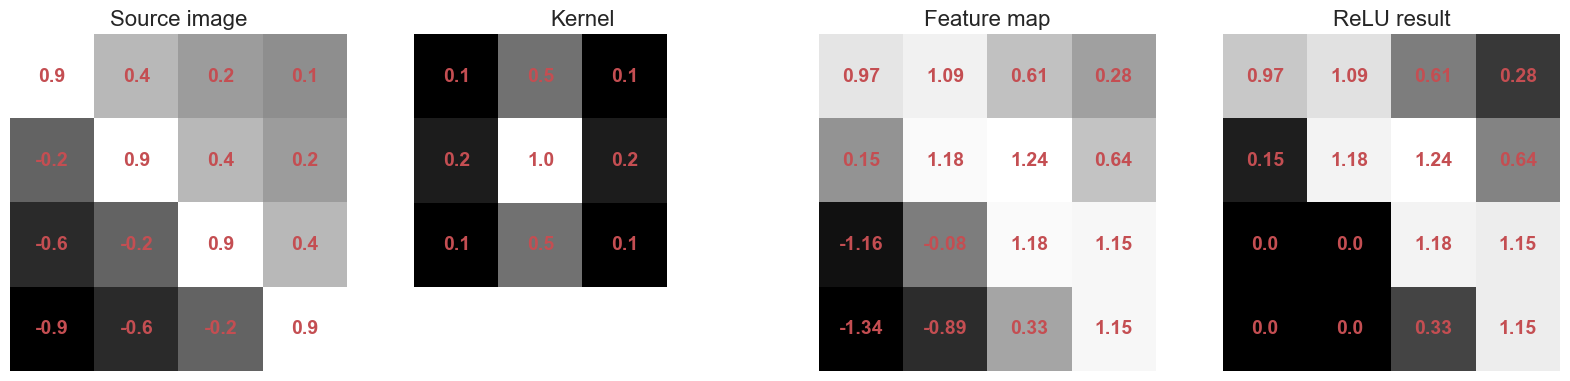

In [4]:
x = cn(img[(None, )*2]).detach() # reshape the tensor and convolve with a filter

f, ax = plt.subplots(1, 4, figsize=(20,5), sharex=True, sharey=True)
im = [img, cn.weight.data.squeeze(), x.squeeze(), F.relu(x).squeeze()]
txt = ["Source image", "Kernel", "Feature map", "ReLU result"]
for i in range(0,4): 
    p = ax[i].imshow(im[i], cmap='gray', interpolation='None')
    ax[i].axis('off')
    ax[i].set_title(txt[i], fontsize=16)
    hp.annotate(im[i], ax[i])
print("Output shape: {}".format(x.shape))

In [5]:
from torchvision import datasets, transforms
from PIL import Image

to_image = transforms.ToPILImage(mode="RGB")
to_tensor = transforms.ToTensor()

def conv_ex(filters, i=0, intensity=5, stride=1, padding=1, dilation=0):
    img = Image.open('./images/puppy.jpeg')
    f, ax = plt.subplots(1, 3, figsize=(20,5))
    cv = torch.nn.Conv2d(3,3,3, stride=stride, padding=padding, dilation=dilation)
    flt = torch.FloatTensor(filters[i]).repeat((3,3,1,1))
    flt.divide_(intensity)
    cv.bias = torch.nn.Parameter(torch.zeros(3))
    cv.weight =  torch.nn.Parameter(flt)
    x = to_tensor(img)
    conv = cv(x.unsqueeze(0)).detach().squeeze()
    ax[0].imshow(img)
    ax[1].imshow(to_image(conv))
    ax[2].imshow(to_image(F.relu(conv)))
    for a in ax.flatten(): a.axis('off')
    print("{} -> {}".format(x.shape,  conv.shape))
    plt.show()

## Example: convolutional layer

- Apply 4 filters with dimensions 3x3x3, which are generated from the 3x3 matrices stored in `flts`
- For each filter a raw output image and its rectified version are shown

- **Conv2D**: Computation of the input and output shapes (2D case - 2 equations)
    - $P$ - padding, $D$ - dilation, $K$ - kernel size, $S$ - stride, $N$ - number of examples
    - for $x \in \{\mathit{in, out}\}$: $C_{x}$ - channels, $H_{x}$ - height, $W_{x}$ - width
    - Input: $(N, C_{\mathit{in}}, W_{\mathit{in}}, H_{\mathit{in}})$
        - Example: $N=64$, $C_{\mathit{in}}=1$, $H_{\mathit{in}}=28$, $W_{\mathit{in}}=28$
    - Output: $(N, C_{\mathit{out}}, W_{\mathit{out}}, H_{\mathit{out}})$
        - Example: $N=64$, $C_{\mathit{out}}$ - defined by the layer
    
\begin{align*}
H_{out} &= \left\lfloor 1+\frac{H_{in}  + 2 \times P[0] - D[0]
          \times (K[0] - 1) - 1}{S[0]}\right\rfloor \\
W_{out} &= \left\lfloor 1+\frac{W_{in}  + 2 \times P[1] - D[1]
          \times (K[1] - 1) - 1}{S[1]}\right\rfloor    
\end{align*}

In [16]:
flts = np.array([
    [[1,0,-1],[1,0,-1],[1,0,-1]],
    [[-1,-1,-1],[0,0,0],[1,1,1]],
    [[0,-1,0],[-1,4,-1],[0,-1,0]],
    [[1/32,1/16,1/32],[1/16,1/8,1/16],[1/32,1/16,1/32]]
])

interact(conv_ex, filters=fixed(flts), i=(0,3,1), intensity=(1,10,1), stride=(1,10,1), 
         padding=(0,5,1), dilation=(1,10,1));

interactive(children=(IntSlider(value=0, description='i', max=3), IntSlider(value=5, description='intensity', …

## Auxiliary layers

- Pooling
  - Compute maximum/average values of a region of a previous layer
  - Used to perform downsampling, i.e., to reduce spatial size (height, width), and thus reduce the amount of parameters in the network and control overfitting
  - Commonly inserted between convolutional layers

- **MaxPool2D**: extracts a maximum value for each position of a 2D kernel 

\begin{align}
    out(N_i, C_j, h, w) ={} & \max_{m=0, \ldots, K[0]-1} \max_{n=0, \ldots, K[1]-1} \\
                            & \text{input}(N_i, C_j, S[0] \times h + m, S[1] \times w + n)
\end{align}

- Output size is computed as for the convolutional layer
  - Example: MaxPool2D with a $2\times 2$ kernel and stride $2$ results in an output, which is 4 times smaller than the input
- Usually applied to each channel of an activation map independently
- Applications over multiple channels allows the network to learn other invariances, like rotational invariance, in addition to the translation invariance
- Variance in stride enables processing of images of varying sizes

## Auxiliary layers

- **Flattening**
  - Transform multi-dimensional input into single-dimensional
  - Used as a transition layer between, e.g., convolutional and dense layers
- **Dropout**
  - Regularization layer that is used to prevent the network from overfitting (works only during the training process)
  - Usually placed after a dense layer
  - Signals of neurons from the previous layer are propagated only with some probability $p$

## MNIST Example

- MNIST is dataset comprising 60000 handwritten digits
- Each image has 1 channel (grayscale) and is 28x28 pixels

In [7]:
# fast conversion of the data set into pytorch tensors
# transform the PILImage images of range [0, 1] to an extended range
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.2,), (0.3,))])

cuda_args = {'num_workers': 1, 'pin_memory': True, 'shuffle': True}

dataset1 = datasets.MNIST('../data', train=True, download=True, transform=transform)
dataset2 = datasets.MNIST('../data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1, batch_size=64, **cuda_args)
test_loader = torch.utils.data.DataLoader(dataset2, batch_size=1024, **cuda_args)

Batch: 0, images: torch.Size([1024, 1, 28, 28]), targets: torch.Size([1024])


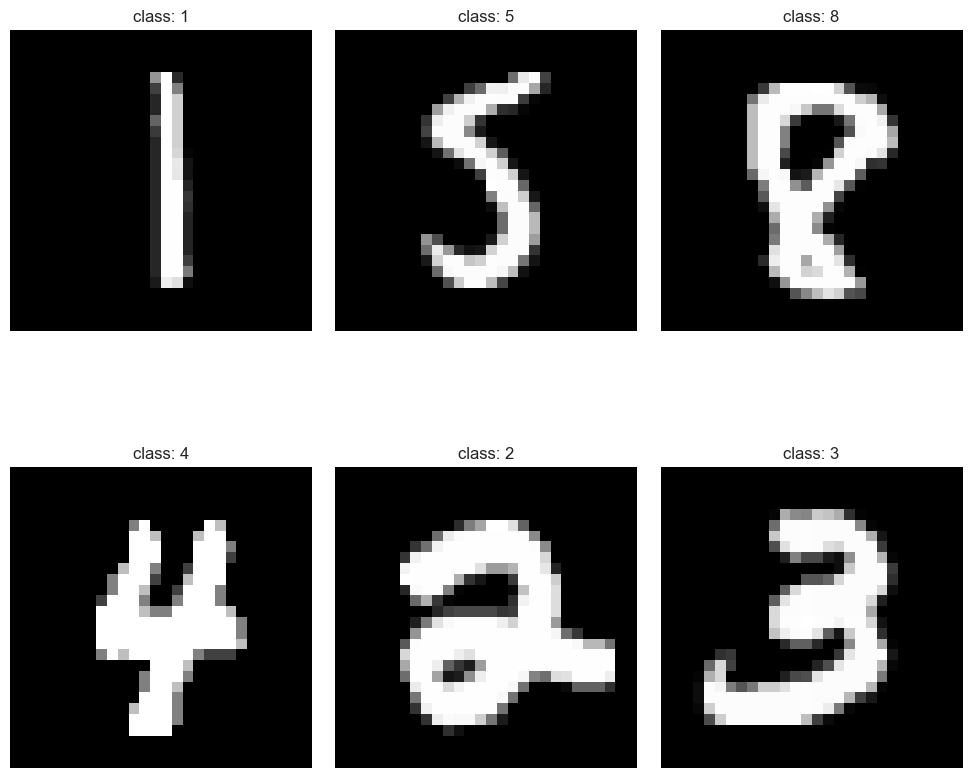

Mean:-0.4839935600757599 and std:0.6993585228919983 of the first image


In [8]:
# get the first batch
test_enum = enumerate(test_loader)
batch_id, (images, targets) = next(test_enum)
print("Batch: {}, images: {}, targets: {}".format(batch_id, images.shape, targets.shape))

# show the first 6 images
fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray', interpolation='none')
    plt.title("class: {}".format(targets[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()
print('Mean:{} and std:{} of the first image'.format(images[0][0].mean(), images[0][0].std()))

## MNIST - DNN Architecture

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/dnn-mnist.png" width="30%"/>
</center>

In [9]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # input shape 1x28x28, defaults: S = 1, P = 0, D = 1
        # C_in = 1, C_out = 32, K = 3
        self.conv1 = torch.nn.Conv2d(1, 32, 3)
        # H_out = floor(1+(28+2*0-1*(3-1)-1)/1) = 26
        # W_out = ... = 26
        self.conv2 = torch.nn.Conv2d(32, 64, 3)
        self.fc1 = torch.nn.Linear(9216, 128)
        self.dropout = torch.nn.Dropout(0.25)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        # input 26*26*32
        x = self.conv2(x)
        x = F.relu(x)
        # input 24*24*64
        x = F.max_pool2d(x, 2)
        # output = 12*12*32
        x = torch.flatten(x, 1)
        # output = 9216
        x = F.relu(self.fc1(x))
        # output = 128
        x = self.dropout(x)
        return F.log_softmax(self.fc2(x), dim=1)
        
model = Net()
img=torch.randn((1,1,28,28))
print(model(img).exp())
print(model)

tensor([[0.1088, 0.0928, 0.0815, 0.1078, 0.0988, 0.1105, 0.0904, 0.0839, 0.1130,
         0.1126]], grad_fn=<ExpBackward0>)
Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
def train(model, device, train_loader, opt, epoch):
    model.train()
    for batch_id, (images, target) in enumerate(train_loader):
        images, target = images.to(device), target.to(device)
        opt.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, target)
        loss.backward()
        opt.step()

In [11]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for images, target in test_loader:
            images, target = images.to(device), target.to(device)
            output = model(images)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    return test_loss

In [12]:
from torch.optim.lr_scheduler import StepLR

dev_name = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using {} to traing the model".format(dev_name))
device = torch.device(dev_name)

model = Net().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

# Decreases the learning rate of each parameter group by gamma every 1 epoch
scheduler = StepLR(opt, step_size=1, gamma=0.7)
for epoch in range(1, 2):
    train(model, device, train_loader, opt, epoch)
    t_loss = test(model, device, test_loader)
    scheduler.step()

Using mps to traing the model

Test set: Average loss: 0.0392, Accuracy: 9871/10000 (99%)



In [13]:
def classify(model, device, dataloader):
    model.eval()
    correct=[]
    incorrect=[]
    with torch.no_grad():
        for images, target in dataloader:
            d_images, d_target = images.to(device), target.to(device)
            output = model(d_images)
            out_c = output.detach().cpu()
            pred = output.argmax(dim=1, keepdim=True)
            for val,i in zip(pred.eq(d_target.view_as(pred)).cpu(), range(images.size(0))):
                if val:
                    correct.append((images[i], target[i], out_c[i,:]))
                else:
                    incorrect.append((images[i], target[i], out_c[i,:]))
                
    return correct, incorrect 

corr, incorr = classify(model, device, test_loader)

In [14]:
@interact(img=(0,10,1))
def plot_results(img=7):
    t = incorr
    f, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(t[img][0][0], cmap='gray', interpolation='none')
    ax[0].title.set_text("class: {}".format(t[img][1]))
    ax[1].bar(range(10),torch.exp(t[img][2]))
    ax[1].set_yscale('linear')
    plt.show()

interactive(children=(IntSlider(value=7, description='img', max=10), Output()), _dom_classes=('widget-interact…

In [15]:
model = torch.nn.Sequential(
        torch.nn.Conv2d(1, 32, 3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(2),
        torch.nn.Dropout(0.25),
        torch.nn.Flatten(),
        torch.nn.Linear(5408, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 10),
        torch.nn.LogSoftmax(1)
        )
print(model)
print(model(torch.randn((1,1,28,28))))

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.25, inplace=False)
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=5408, out_features=128, bias=True)
  (6): ReLU()
  (7): Linear(in_features=128, out_features=10, bias=True)
  (8): LogSoftmax(dim=1)
)
tensor([[-2.5982, -2.3220, -2.1333, -2.0033, -2.2702, -2.4988, -2.5970, -2.5651,
         -2.2114, -2.0578]], grad_fn=<LogSoftmaxBackward0>)


# Visualizations

https://poloclub.github.io/cnn-explainer/

https://fredhohman.com/summit/

https://cs.stanford.edu/people/karpathy/convnetjs/
